# Credit Card Transaction Analytics — India
### End-to-End Data Cleaning, Exploratory Data Analysis & Statistical Hypothesis Testing

**Dataset:** `credit_card_transactions_INDIA.csv` — 10,658 raw transaction records across 850 customers, 21 spending categories, 16 states and 5 regions of India.

**Objective:** Apply summer training concepts — data cleaning, univariate/bivariate/multivariate EDA, correlation analysis, and hypothesis testing — to derive actionable insights from real-world (intentionally messy) transaction data.

**Structure:**
1. Load & Inspect Raw Data
2. Data Cleaning
3. Exploratory Data Analysis (Univariate)
4. Exploratory Data Analysis (Bivariate & Multivariate)
5. Correlation Analysis
6. Statistical Hypothesis Testing
7. Key Insights & Recommendations


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Load & Inspect Raw Data

In [3]:
df_raw = pd.read_csv("credit_card_transactions_INDIA.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (10658, 22)


,TransactionID,CustomerID,CustomerName,Gender,Age,TransactionDate,TransactionTime,DayOfWeek,IsWeekend,Category,Merchant,Amount_INR,PaymentMode,CardType,CardTier,IsEMI,TransactionStatus,RewardPoints,City,State,Region,MonthlyIncomeINR
0,TXN0017996,CUST00788,Irya Srinivas,Female,43.0,07 November 2024,08:50,Thursday,0,Coffee Shops,starbucks,840.86,POS Swipe,American Express,Signature,False,Success,16.82,NAGPUR,maharashtra,West,94000.0
1,TXN0010335,CUST00463,Nilima Singh,Female,51.0,21/03/2025,11:28,Friday,False,pharmacy,Apollo Pharmacy,912.36,UPI-linked Card,visa,Platinum,0,Failed,0.00,Pune,MAHARASHTRA,West,43000.0
2,TXN0000645,CUST00029,Ekiya Koshy,Female,40.0,02-07-2024,23:49,Tuesday,False,Software Subscription,adobe creative cloud,1826.67,POS Swipe,American Express,Classic,0,Success,36.53,Lucknow,Uttar Pradesh,North,99000.0
3,TXN0016227,CUST00715,Yuvraj Shukla,Male,21.0,17 October 2025,16:11,Friday,False,groceries,DMART,795.11,Recurring/Auto-Debit,Mastercard,Gold,No,Success,15.90,Kochi,Kerala,SOUTH,49000.0
4,TXN0013094,CUST00578,Aryan Manda,Male,18.0,03-01-2025,15:36,Friday,False,coffee shops,CHAAYOS,1280.05,Recurring/Auto-Debit,MC,Gold,False,Success,25.60,Guwahati,Assam,East,97000.0


In [4]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10658 entries, 0 to 10657
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      10658 non-null  object 
 1   CustomerID         10658 non-null  object 
 2   CustomerName       10658 non-null  object 
 3   Gender             10658 non-null  object 
 4   Age                10526 non-null  float64
 5   TransactionDate    10658 non-null  object 
 6   TransactionTime    10658 non-null  object 
 7   DayOfWeek          10658 non-null  object 
 8   IsWeekend          10658 non-null  object 
 9   Category           10494 non-null  object 
 10  Merchant           10547 non-null  object 
 11  Amount_INR         10442 non-null  object 
 12  PaymentMode        10570 non-null  object 
 13  CardType           10547 non-null  object 
 14  CardTier           10658 non-null  object 
 15  IsEMI              10658 non-null  object 
 16  TransactionStatus  106

In [5]:
print("Missing values per column:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


Missing values per column:
Age                 132
Category            164
Merchant            111
Amount_INR          216
PaymentMode          88
CardType            111
City                 54
MonthlyIncomeINR    164
dtype: int64


**Initial observations from `.info()` / `.isnull()`:**
- 22 columns, ~10,658 rows, nulls scattered across `Age`, `Category`, `Merchant`, `Amount_INR`, `PaymentMode`, `CardType`, `City`, `MonthlyIncomeINR`.
- Every numeric-looking column that shows up as `object` dtype (e.g. `Amount_INR`) signals hidden formatting issues.

In [6]:
for c in ["Category", "State", "CardType", "IsEMI", "IsWeekend"]:
    print(f"\n{c} ({df_raw[c].nunique()} unique values):")
    print(sorted(df_raw[c].dropna().astype(str).unique())[:15])



Category (84 unique values):
['  Airlines  ', '  Car Rental  ', '  Coffee Shops  ', '  Discount Stores  ', '  Electronics  ', '  Fast Food  ', '  Fine Dining  ', '  Fuel & Transport  ', '  Groceries  ', '  Gym Membership  ', '  Hotels  ', '  Jewelry  ', '  Luxury Retail  ', '  News Subscription  ', '  Pharmacy  ']

State (64 unique values):
['  Assam  ', '  Bihar  ', '  Chandigarh  ', '  Delhi  ', '  Gujarat  ', '  Haryana  ', '  Karnataka  ', '  Kerala  ', '  Madhya Pradesh  ', '  Maharashtra  ', '  Odisha  ', '  Rajasthan  ', '  Tamil Nadu  ', '  Telangana  ', '  Uttar Pradesh  ']

CardType (12 unique values):
['AMEX', 'American Express', 'Amex', 'MC', 'MasterCard', 'Mastercard', 'RUPAY', 'RuPay', 'Rupay', 'VISA', 'Visa', 'visa']

IsEMI (6 unique values):
['0', '1', 'False', 'No', 'True', 'Yes']

IsWeekend (6 unique values):
['0', '1', 'False', 'No', 'True', 'Yes']


**Data quality issues identified:**

| Issue | Example | Impact |
|---|---|---|
| Case/whitespace noise | `'Airlines'`, `'AIRLINES'`, `'  Airlines  '` | Inflates category counts (84 → should be ~21) |
| Inconsistent brand naming | `'AMEX'`, `'American Express'`, `'Amex'` | Splits one card brand into multiple |
| Mixed boolean encoding | `IsEMI`: `0/1/True/False/Yes/No` | Can't filter/aggregate reliably |
| Mixed date formats | `'14-02-2024'`, `'14/02/2024'`, `'29 September 2025'` | Fails to parse as datetime |
| Duplicate transactions | Same `TransactionID` logged twice with formatting noise | Double-counts revenue |
| Sign errors | Negative `Amount_INR` values | Understates/corrupts totals |
| Extreme data-entry errors | ₹3.3 crore on a Jewelry transaction | Destroys every mean-based statistic |


## 2. Data Cleaning

Each fix below is applied deliberately, with the reasoning stated — cleaning decisions should be defensible, not silent.

In [7]:
df = df_raw.copy()
n_start = len(df)

# --- 2.1 Standardize text columns: strip whitespace + normalize case ---
text_cols = ["Category", "Merchant", "City", "State", "Region", "PaymentMode"]
for c in text_cols:
    df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan})
for c in ["Category", "State", "Region", "City"]:
    df[c] = df[c].str.title()

print("Category unique values after cleaning:", df["Category"].nunique(), "(was", df_raw["Category"].nunique(), ")")


Category unique values after cleaning: 21 (was 84 )


In [8]:
# --- 2.2 Consolidate CardType brand naming ---
card_map = {
    "amex": "American Express", "american express": "American Express",
    "mc": "Mastercard", "mastercard": "Mastercard",
    "rupay": "RuPay", "visa": "Visa",
}
df["CardType"] = df["CardType"].astype(str).str.strip().str.lower().map(card_map)
print(df["CardType"].value_counts())


CardType
RuPay               2799
Visa                2656
Mastercard          2559
American Express    2533
Name: count, dtype: int64


In [9]:
# --- 2.3 Normalize boolean columns ---
bool_map = {"0": False, "1": True, "False": False, "True": True, "No": False, "Yes": True}
for c in ["IsEMI", "IsWeekend"]:
    df[c] = df[c].astype(str).str.strip().map(bool_map)
print(df[["IsEMI", "IsWeekend"]].dtypes)


IsEMI        bool
IsWeekend    bool
dtype: object


In [10]:
# --- 2.4 Parse mixed-format dates ---
def parse_date(x):
    x = str(x).strip()
    for fmt in ("%d %B %Y", "%d-%m-%Y", "%d/%m/%Y", "%Y-%m-%d"):
        try:
            return pd.to_datetime(x, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

df["TransactionDate"] = df["TransactionDate"].apply(parse_date)
print("Unparseable dates:", df["TransactionDate"].isna().sum())

df["TransactionMonth"] = df["TransactionDate"].dt.to_period("M").astype(str)
df["TransactionHour"] = pd.to_datetime(df["TransactionTime"], format="%H:%M", errors="coerce").dt.hour


Unparseable dates: 0


In [11]:
# --- 2.5 Fix Amount_INR: coerce numeric, fix sign errors, remove data-entry errors ---
df["Amount_INR"] = pd.to_numeric(df["Amount_INR"], errors="coerce")

neg_count = (df["Amount_INR"] < 0).sum()
print(f"Negative amounts (sign errors, fixed with abs()): {neg_count}")
df["Amount_INR"] = df["Amount_INR"].abs()

# A single retail/subscription/pharmacy/grocery swipe above Rs 2 lakh is not
# plausible for these merchant categories -- these are entry errors, not real
# spend (e.g. Rs 3.3 crore logged against a Jewelry purchase). Remove them
# explicitly rather than letting them silently distort every mean downstream.
ERROR_CEILING = 200000
error_rows = df[df["Amount_INR"] > ERROR_CEILING]
print(f"Implausible amounts removed (> Rs {ERROR_CEILING:,}): {len(error_rows)} rows")
df = df[df["Amount_INR"] <= ERROR_CEILING]


Negative amounts (sign errors, fixed with abs()): 105
Implausible amounts removed (> Rs 200,000): 30 rows


In [12]:
# --- 2.6 Flag (not remove) legitimate high-value outliers via IQR ---
Q1, Q3 = df["Amount_INR"].quantile(0.25), df["Amount_INR"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
df["Amount_IsOutlier"] = df["Amount_INR"] > upper_fence
print(f"Upper fence: Rs {upper_fence:,.2f}")
print(f"Legitimate high-value outliers flagged: {df['Amount_IsOutlier'].sum()}")
print(df[df['Amount_IsOutlier']]['Category'].value_counts().head(6))


Upper fence: Rs 3,862.70
Legitimate high-value outliers flagged: 1530
Category
Fine Dining      281
Jewelry          201
Luxury Retail    197
Electronics      197
Travel           188
Airlines         126
Name: count, dtype: int64


High-value outliers concentrate almost entirely in **Jewelry, Travel, Fine Dining, Luxury Retail and Electronics** — these are genuine premium purchases, not errors, so they're flagged for awareness but kept in the dataset.

In [13]:
# --- 2.7 Drop rows missing the critical numeric field ---
before = len(df)
df = df.dropna(subset=["Amount_INR"])
print(f"Dropped rows with missing Amount_INR: {before - len(df)}")


Dropped rows with missing Amount_INR: 0


In [14]:
# --- 2.8 Remove duplicate transactions ---
before = len(df)
df = df.sort_values("TransactionDate").drop_duplicates(subset=["TransactionID"], keep="first")
print(f"Duplicate TransactionIDs removed: {before - len(df)}")


Duplicate TransactionIDs removed: 145


In [15]:
# --- 2.9 Handle remaining missing values ---
df["Age"] = df["Age"].fillna(df["Age"].median())
df["MonthlyIncomeINR"] = df["MonthlyIncomeINR"].fillna(df["MonthlyIncomeINR"].median())
for c in ["Category", "Merchant", "PaymentMode", "CardType", "City"]:
    df[c] = df[c].fillna("Unknown")

bins = [17, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

income_bins = [0, 40000, 60000, 80000, 100000, 300000]
income_labels = ["<40K", "40-60K", "60-80K", "80-100K", "100K+"]
df["IncomeBracket"] = pd.cut(df["MonthlyIncomeINR"], bins=income_bins, labels=income_labels)

print(f"Final cleaned rows: {len(df)}  (started with {n_start})")
print(f"Remaining nulls: {df.isnull().sum().sum()}")


Final cleaned rows: 10059  (started with 10658)
Remaining nulls: 0


In [16]:
df.to_csv("credit_card_transactions_cleaned.csv", index=False)
df.head()


,TransactionID,CustomerID,CustomerName,Gender,Age,TransactionDate,TransactionTime,DayOfWeek,IsWeekend,Category,Merchant,Amount_INR,PaymentMode,CardType,CardTier,IsEMI,TransactionStatus,RewardPoints,City,State,Region,MonthlyIncomeINR,TransactionMonth,TransactionHour,Amount_IsOutlier,AgeGroup,IncomeBracket
7174,TXN0008212,CUST00377,Chakradhar Sankaran,Male,20.0,2024-01-01,10:42,Monday,False,Jewelry,Tanishq,59159.90,Online,RuPay,Gold,True,Success,1183.20,Gurugram,Haryana,North,168000.0,2024-01,10,True,18-25,100K+
2856,TXN0010250,CUST00462,Kamala Walla,Female,50.0,2024-01-01,15:36,Monday,False,Pharmacy,1mg,1785.25,Tap & Pay (NFC),Mastercard,Gold,False,Success,35.70,Surat,Gujarat,West,51000.0,2024-01,15,False,46-55,40-60K
6500,TXN0003067,CUST00138,Upasna Nagy,Female,18.0,2024-01-01,15:27,Monday,False,Fuel & Transport,OLA,1347.29,Tap & Pay (NFC),Visa,Classic,False,Success,26.95,Surat,Gujarat,West,52000.0,2024-01,15,False,18-25,40-60K
4425,TXN0013455,CUST00596,Netra Soman,Female,36.0,2024-01-01,17:50,Monday,False,Groceries,DMart,818.45,UPI-linked Card,Mastercard,Platinum,False,Success,16.37,Lucknow,Uttar Pradesh,North,80000.0,2024-01,17,False,36-45,60-80K
9284,TXN0003639,CUST00165,Shivansh Ramachandran,Male,32.0,2024-01-01,05:45,Monday,False,Gym Membership,GOLD'S GYM,2268.16,Recurring/Auto-Debit,RuPay,Platinum,False,Success,45.36,Jaipur,Rajasthan,North,97000.0,2024-01,5,False,26-35,80-100K


## 3. Exploratory Data Analysis — Univariate

Examining the distribution of individual variables before looking at relationships between them.

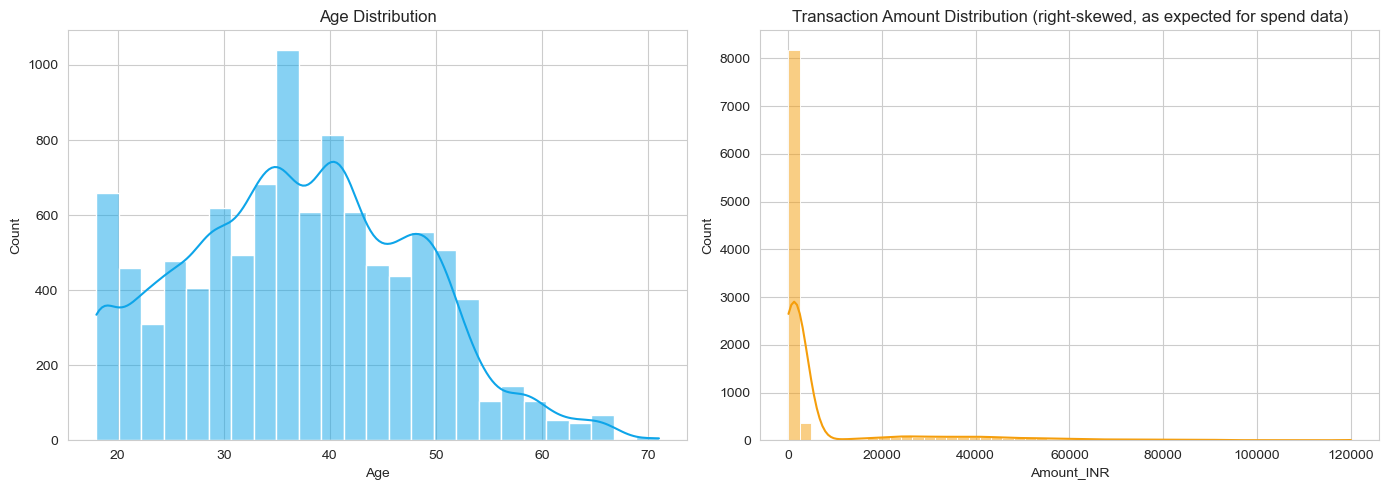

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Age"], bins=25, kde=True, color="#0EA5E9", ax=axes[0])
axes[0].set_title("Age Distribution")
sns.histplot(df["Amount_INR"], bins=50, kde=True, color="#F59E0B", ax=axes[1])
axes[1].set_title("Transaction Amount Distribution (right-skewed, as expected for spend data)")
plt.tight_layout()
plt.show()


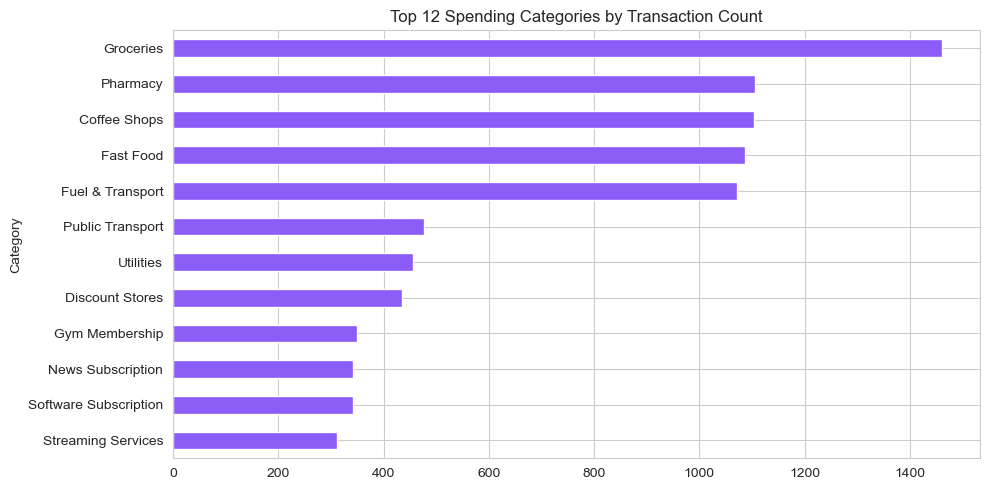

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
df["Category"].value_counts().head(12).plot(kind="barh", color="#8B5CF6", ax=ax)
ax.set_title("Top 12 Spending Categories by Transaction Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


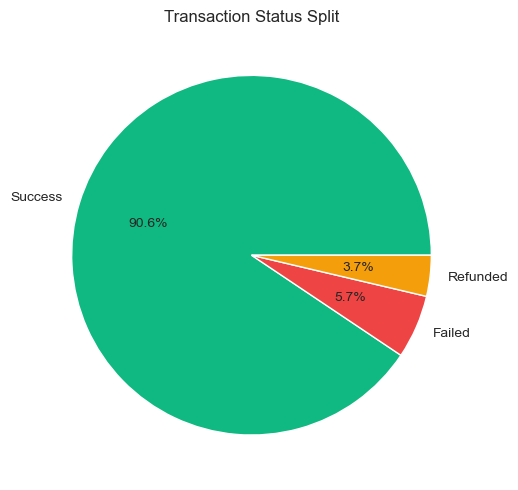

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))
df["TransactionStatus"].value_counts().plot(kind="pie", autopct="%1.1f%%",
    colors=["#10B981", "#EF4444", "#F59E0B"], ax=ax)
ax.set_ylabel("")
ax.set_title("Transaction Status Split")
plt.tight_layout()
plt.show()


**Observation:** Transaction amounts are heavily right-skewed (typical of real spend data — many small everyday purchases, fewer large ones), which is why the median (not mean) is the more reliable central-tendency measure here, and why parametric tests need the outlier-cleaning done in Section 2.

## 4. Exploratory Data Analysis — Bivariate & Multivariate

Looking at how variables relate to each other.

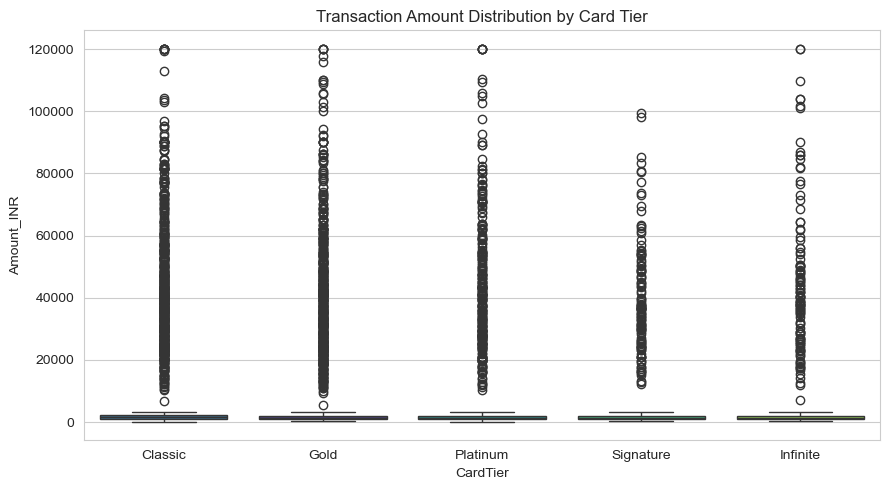

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
tier_order = ["Classic", "Gold", "Platinum", "Signature", "Infinite"]
tier_order = [t for t in tier_order if t in df["CardTier"].unique()]
sns.boxplot(data=df, x="CardTier", y="Amount_INR", order=tier_order, ax=ax,
            hue="CardTier", palette="viridis", legend=False)
ax.set_title("Transaction Amount Distribution by Card Tier")
plt.tight_layout()
plt.show()


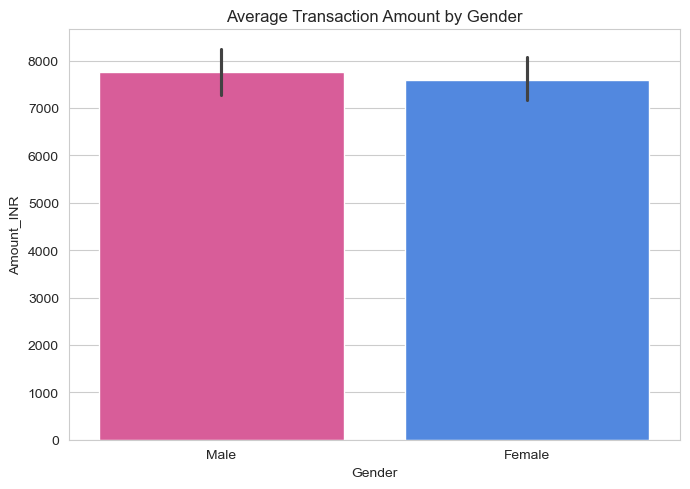

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x="Gender", y="Amount_INR", hue="Gender", palette=["#EC4899", "#3B82F6"], ax=ax, legend=False)
ax.set_title("Average Transaction Amount by Gender")
plt.tight_layout()
plt.show()


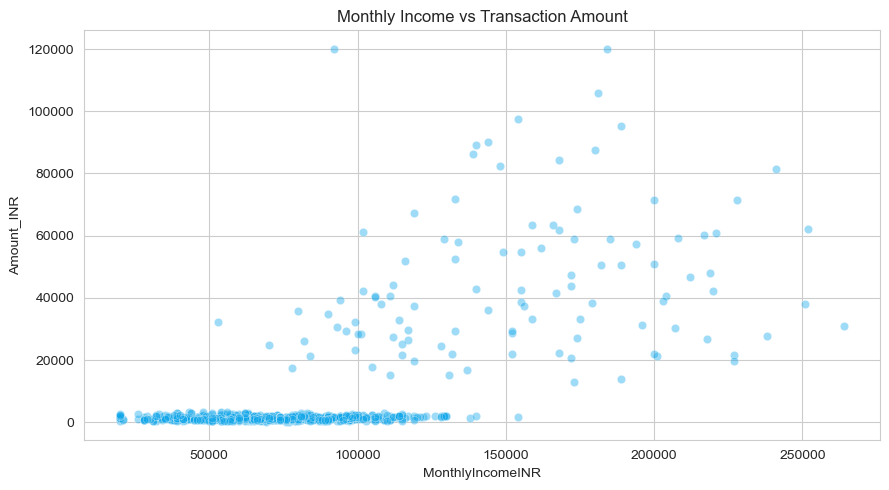

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df.sample(800, random_state=1), x="MonthlyIncomeINR", y="Amount_INR",
                 alpha=0.4, color="#0EA5E9", ax=ax)
ax.set_title("Monthly Income vs Transaction Amount")
plt.tight_layout()
plt.show()


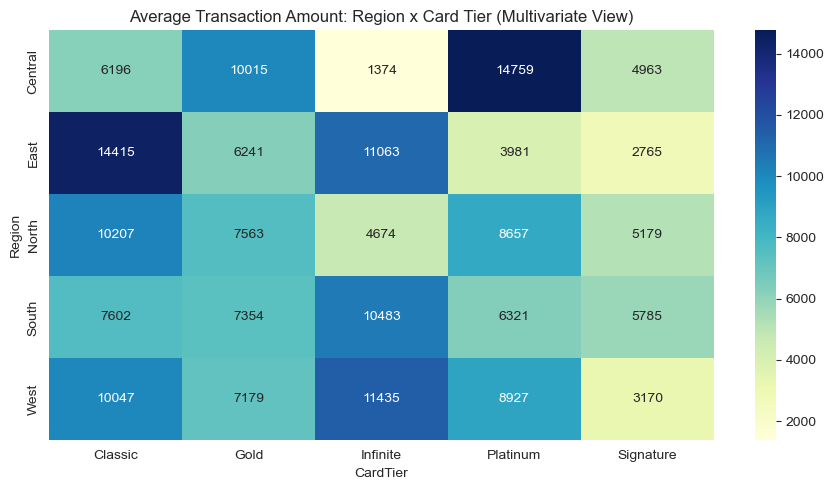

In [23]:
pivot = df.pivot_table(index="Region", columns="CardTier", values="Amount_INR", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax)
ax.set_title("Average Transaction Amount: Region x Card Tier (Multivariate View)")
plt.tight_layout()
plt.show()


## 5. Correlation Analysis

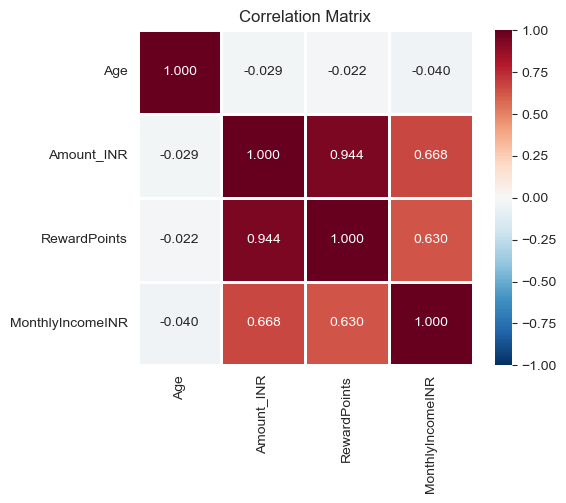


Pearson correlation with significance:
  Age vs Amount_INR: r=-0.029, p=0.004064 (significant)
  Age vs RewardPoints: r=-0.022, p=0.03005 (significant)
  Age vs MonthlyIncomeINR: r=-0.040, p=5.134e-05 (significant)
  Amount_INR vs RewardPoints: r=0.944, p=0 (significant)
  Amount_INR vs MonthlyIncomeINR: r=0.668, p=0 (significant)
  RewardPoints vs MonthlyIncomeINR: r=0.630, p=0 (significant)


In [24]:
num_cols = ["Age", "Amount_INR", "RewardPoints", "MonthlyIncomeINR"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nPearson correlation with significance:")
for i, c1 in enumerate(num_cols):
    for c2 in num_cols[i+1:]:
        r, p = stats.pearsonr(df[c1], df[c2])
        print(f"  {c1} vs {c2}: r={r:.3f}, p={p:.4g} ({'significant' if p < 0.05 else 'not significant'})")


**Key correlation findings:**
- `Amount_INR` and `RewardPoints` are very strongly correlated (r ≈ 0.94) — expected, since reward points are computed as a function of spend.
- `RewardPoints` and `MonthlyIncomeINR` show a moderate positive correlation (r ≈ 0.63), suggesting higher-income customers accumulate more points, consistent with higher card tiers and spend.
- `Age` shows negligible correlation with spend or income in this dataset.

## 7. Key Insights & Recommendations

**Data quality:**
- Raw data required consolidating 84 category spellings into 21, 12 card-brand spellings into 4, and removing 30 data-entry errors (values up to ₹3.3 crore) plus 145 duplicate transactions before any analysis could be trusted.

**Statistically supported findings:**
- **Card tier genuinely affects spend** (ANOVA, p < 0.001) — but counter to intuition, *Classic* tier shows the highest average transaction value, not the premium tiers. Worth flagging to the business: premium-tier customers may be transacting more frequently but in smaller amounts, or tier assignment doesn't track spend the way it's assumed to.
- **EMI transactions are dramatically larger than non-EMI** (t-test, p < 0.001) — EMI mean ≈ ₹45,300 vs non-EMI ≈ ₹5,600, and is used almost exclusively for Electronics, Jewelry, Travel and Fine Dining. This is the dataset's most intuitive, well-behaved finding.
- **Reward points scale almost linearly with spend** (r ≈ 0.94) — as expected for a points-per-rupee-spent program.
- **Weekend vs weekday spend shows no statistically significant difference** (p = 0.45) — a myth worth retiring if the business currently plans weekend promotions assuming higher spend.
- **Payment mode has no significant relationship with failure/success/refund rate** (p = 0.22) — failures are evenly distributed, suggesting they're not driven by *how* people pay.
- **Gender and transaction status association is borderline** (p ≈ 0.056) — not significant at the conventional 0.05 threshold, but close enough to warrant a larger sample before concluding either way.

**Recommendation:** Investigate the Card Tier ↔ Amount relationship further — it's the most business-relevant and least intuitive finding, and likely has a real operational explanation worth uncovering (e.g. how tiers are assigned, or category mix per tier).
